[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026_CS1090B_public/blob/main/sec10/cs1090b_sec10_solutions.ipynb)

# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png">

# CS1090B Section 10: BERT & GPT with Hugging Face

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb<br/>

## Overview

In this section we get hands-on with two landmark transformer architectures covered in Lectures 18 and 19. We will:

- Explore the **Hugging Face** `transformers` library and its `AutoModel` / `AutoTokenizer` API
- Understand how **tokenization** works: encoding, special tokens, padding, and truncation
- **Fine-tune DistilBERT** (an encoder model) for binary sentiment classification on IMDb reviews
- **Fine-tune DistilGPT-2** (a decoder model) for text generation on a domain-specific corpus
- Compare **encoder** (BERT-family) vs **decoder** (GPT-family) models conceptually
- Use Hugging Face **Pipelines** for quick NLP inference

## Setup: Download Data

**Note: GPU required for this section**

We will use the Hugging Face `datasets` library for IMDb and download a small COVID-related text corpus for GPT-2 fine-tuning.

In [1]:
# Environment detection and setup
import os
import subprocess
import sys
import shutil
import zipfile
import urllib.request

# --- Download notebook assets (figures, data) ---
assets_zip_url = "https://github.com/Harvard-CS1090/2026_CS1090B_public/raw/main/sec10/notebook_assets.zip"
assets_zip_name = "notebook_assets.zip"
expected_dirs = ["data", "fig"]

all_dirs_exist = all(os.path.isdir(d) for d in expected_dirs)

if all_dirs_exist:
    print("Required directories already exist. Skipping asset download.")
else:
    print(f"Downloading {assets_zip_name} from GitHub...")
    try:
        if 'google.colab' in sys.modules:
            subprocess.run(['wget', '-q', assets_zip_url], check=True)
        else:
            urllib.request.urlretrieve(assets_zip_url, assets_zip_name)
        with zipfile.ZipFile(assets_zip_name, "r") as zip_ref:
            zip_ref.extractall(".")
        os.remove(assets_zip_name)
        if os.path.isdir('__MACOSX'):
            shutil.rmtree('__MACOSX')
        print("Asset download complete.")
    except Exception as e:
        print(f"Error during asset setup: {e}", file=sys.stderr)

print("Setup complete!")

Required directories already exist. Skipping asset download.
Setup complete!


In [2]:
# Install required libraries (Colab already has torch)
# !pip install -q transformers datasets

import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    pipeline,
)
from datasets import load_dataset

# Reproducibility
np.random.seed(109)
random.seed(109)
torch.manual_seed(109)

time_start = time.time()

/home/rashmi/miniconda3/envs/mdc2env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 5090


## Part 1: Hugging Face & Tokenization

[Hugging Face](https://huggingface.co/) is the go-to open-source platform for NLP and generative AI. Its `transformers` library provides a unified API to load, fine-tune, and deploy thousands of pre-trained models.

Key concepts we will cover:
- **AutoModel** / **AutoTokenizer** — model-agnostic loading
- **Tokenization** — converting text to model-ready inputs
- Special tokens, padding, and truncation

### AutoModel

Without `Auto` classes, you'd need to import the exact model class for each architecture — e.g., `DistilBertForSequenceClassification` for DistilBERT, `RobertaForSequenceClassification` for RoBERTa, etc. The `Auto` classes solve this: you just pass the checkpoint name (like `"distilbert-base-uncased"`) and the library looks up the correct class from the model's config. This makes it easy to swap models with a single string change.

In [4]:
# Load a DistilBERT model — AutoModel figures out the correct class
model_demo = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
print(type(model_demo))
print(f'Parameters: {sum(p.numel() for p in model_demo.parameters()):,}')

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'>
Parameters: 66,955,010


In [5]:
# Inspect the config
model_demo.config

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.56.2",
  "vocab_size": 30522
}

### AutoTokenizer

Nearly every NLP task begins with a **tokenizer**. A tokenizer converts raw text into a format the model can process — a sequence of integer token IDs.

**Important:** Always load the tokenizer using the **same checkpoint string** as the model (e.g., both use `"distilbert-base-uncased"`). Each model was trained with a specific tokenizer and vocabulary — using a mismatched tokenizer will produce wrong token IDs and garbage results.

In [6]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

In [7]:
# Tokenize a sentence
encoded = tokenizer('There are only 2 sections left!')
print('Keys:', encoded.keys())
print('Token IDs:', encoded['input_ids'])
print('Attention mask:', encoded['attention_mask'])

Keys: KeysView({'input_ids': [101, 2045, 2024, 2069, 1016, 5433, 2187, 999, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]})
Token IDs: [101, 2045, 2024, 2069, 1016, 5433, 2187, 999, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]


In [8]:
# Decode back to text — notice the special [CLS] and [SEP] tokens
tokenizer.decode(encoded['input_ids'])

'[CLS] there are only 2 sections left! [SEP]'

The tokenizer automatically added two special tokens:
- **[CLS]** (classifier token) — placed at the start; its output embedding is typically used for classification tasks
- **[SEP]** (separator token) — marks the end of a sentence (or separates two sentences)

### Batch Encoding, Padding & Truncation

In practice we tokenize **batches** of sentences. Since sentences have different lengths, we need:
- **Padding** — add special `[PAD]` tokens so all sequences have the same length
- **Truncation** — cut sequences that exceed the model's maximum context window

The `attention_mask` tells the model which tokens are real (1) and which are padding (0).

In [9]:
batch_sentences = [
    'But what about second breakfast?',
    "Don't think he knows about second breakfast, Pip.",
    'What about elevensies?',
]

# Without padding — sequences have different lengths
encoded_no_pad = tokenizer(batch_sentences)
for i, ids in enumerate(encoded_no_pad['input_ids']):
    print(f'Sentence {i}: {len(ids)} tokens')

Sentence 0: 8 tokens
Sentence 1: 14 tokens
Sentence 2: 7 tokens


In [10]:
# With padding — all sequences padded to the longest in the batch
encoded_padded = tokenizer(batch_sentences, padding=True)
for i, ids in enumerate(encoded_padded['input_ids']):
    print(f'Sentence {i}: {len(ids)} tokens  |  IDs: {ids}')
print()
print('Attention masks:')
for i, mask in enumerate(encoded_padded['attention_mask']):
    print(f'Sentence {i}: {mask}')

Sentence 0: 14 tokens  |  IDs: [101, 2021, 2054, 2055, 2117, 6350, 1029, 102, 0, 0, 0, 0, 0, 0]
Sentence 1: 14 tokens  |  IDs: [101, 2123, 1005, 1056, 2228, 2002, 4282, 2055, 2117, 6350, 1010, 28315, 1012, 102]
Sentence 2: 14 tokens  |  IDs: [101, 2054, 2055, 5408, 14625, 1029, 102, 0, 0, 0, 0, 0, 0, 0]

Attention masks:
Sentence 0: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
Sentence 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Sentence 2: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]


Notice the trailing `0`s in the token IDs (padding) and the matching `0`s in the attention mask. The model will **ignore** these padded positions during self-attention.

In [11]:
# With padding AND truncation — useful when input may exceed context window
encoded_trunc = tokenizer(
    batch_sentences,
    padding=True,
    truncation=True,
    max_length=8  # artificially small to demonstrate
)
for i, ids in enumerate(encoded_trunc['input_ids']):
    decoded = tokenizer.decode(ids)
    print(f'Sentence {i} ({len(ids)} tokens): {decoded}')

Sentence 0 (8 tokens): [CLS] but what about second breakfast? [SEP]
Sentence 1 (8 tokens): [CLS] don ' t think he knows [SEP]
Sentence 2 (8 tokens): [CLS] what about elevensies? [SEP] [PAD]


### Building PyTorch Tensors

To feed data into a PyTorch model, set `return_tensors='pt'`:

In [12]:
encoded_pt = tokenizer(
    batch_sentences,
    padding=True,
    truncation=True,
    return_tensors='pt'  # PyTorch tensors
)
print('input_ids shape:', encoded_pt['input_ids'].shape)
print('attention_mask shape:', encoded_pt['attention_mask'].shape)
print()
print(encoded_pt['input_ids'])

input_ids shape: torch.Size([3, 14])
attention_mask shape: torch.Size([3, 14])

tensor([[  101,  2021,  2054,  2055,  2117,  6350,  1029,   102,     0,     0,
             0,     0,     0,     0],
        [  101,  2123,  1005,  1056,  2228,  2002,  4282,  2055,  2117,  6350,
          1010, 28315,  1012,   102],
        [  101,  2054,  2055,  5408, 14625,  1029,   102,     0,     0,     0,
             0,     0,     0,     0]])


> **❓ Question 1: Tokenization**
>
> 1. What happens if you tokenize a very long document (say, 1000 words) without setting `truncation=True`? What is DistilBERT's maximum context window?
> 2. Why does the tokenizer return an `attention_mask` alongside `input_ids`? What would go wrong if we didn't use it?
> 3. The token ID for `[PAD]` is 0. Why is it important that the padding token has a fixed, known ID?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. The tokenizer will produce all token IDs (potentially 1000+), but DistilBERT's maximum context window is **512 tokens**. Passing a longer sequence to the model will cause an error. Always use `truncation=True` when inputs may exceed the limit.
> 2. The attention mask tells the model which positions are real tokens vs padding. Without it, the self-attention mechanism would attend to padding tokens as if they were meaningful text, degrading performance.
> 3. The model needs to know which tokens are padding so it can ignore them. A fixed, known ID allows the embedding layer to map padding to a predictable (often zero) vector, and the attention mask to be computed correctly.

</details>

### Context Window Limits

Transformers have a **fixed context window** — DistilBERT's is 512 tokens. Let's see what happens with a long input:

In [13]:
# Create a long text
long_text = ' '.join(['blah'] * 600)

# Tokenize WITHOUT truncation — the tokenizer will warn you
long_encoded = tokenizer(long_text)
print(f'Tokens without truncation: {len(long_encoded["input_ids"])}')

# Tokenize WITH truncation — automatically cuts to model's max length
long_encoded_trunc = tokenizer(long_text, truncation=True)
print(f'Tokens with truncation: {len(long_encoded_trunc["input_ids"])}')

Token indices sequence length is longer than the specified maximum sequence length for this model (602 > 512). Running this sequence through the model will result in indexing errors


Tokens without truncation: 602
Tokens with truncation: 512


## Part 2: Fine-Tuning BERT for Sentence Classification

Now we revisit the familiar task of classifying **IMDb movie reviews** as positive or negative. In earlier sections we built RNN-based classifiers from scratch. Here we'll use **transfer learning** — take a model pre-trained on massive text corpora and fine-tune it on our specific task.

Recall from Lecture 18:
- BERT is an **encoder-only** transformer pre-trained with **Masked Language Modeling (MLM)** and **Next Sentence Prediction (NSP)**
- It produces rich **bidirectional** contextual embeddings
- For classification, we add a linear head on top of the `[CLS]` token output

<img src="./fig/bert_pipeline.png" width="800">

*How to use BERT: Pre-training on large corpora → Fine-tuning on task-specific data → Inference on language tasks (Lecture 18)*

### Data Loading

In [14]:
# Load IMDb dataset from Hugging Face
imdb = load_dataset('imdb')
print(imdb)
print()
print('Example review:')
print(imdb['train'][0]['text'][:300], '...')
print(f"Label: {imdb['train'][0]['label']} (0=negative, 1=positive)")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Example review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...
Label: 0 (0=negative, 1=positive)


In [15]:
# Shuffle and take a subset for faster training in section (full dataset takes ~30 min on GPU)
TRAIN_SIZE = 2000
TEST_SIZE = 500

train_data = imdb['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data = imdb['test'].shuffle(seed=42).select(range(TEST_SIZE))

train_texts = list(train_data['text'])
train_labels = list(train_data['label'])
test_texts = list(test_data['text'])
test_labels = list(test_data['label'])

print(f'Train: {len(train_texts)}, Test: {len(test_texts)}')
print(f'Train label balance: {sum(train_labels)} pos / {len(train_labels)-sum(train_labels)} neg')
print(f'Test label balance: {sum(test_labels)} pos / {len(test_labels)-sum(test_labels)} neg')

Train: 2000, Test: 500
Train label balance: 1000 pos / 1000 neg
Test label balance: 246 pos / 254 neg


### Define Model and Tokenizer

In [16]:
# Load DistilBERT for sequence classification
model_name = 'distilbert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2
).to(device)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model parameters: 66,955,010
Trainable: 66,955,010


### Data Preprocessing

We tokenize all reviews and create a PyTorch `Dataset` for batching:

In [17]:
# DistilBERT supports up to 512 tokens
MAX_LENGTH = 128  # shorter for speed; covers most reviews

# Tokenize all data at once
train_encodings = tokenizer(
    train_texts, truncation=True, padding=True, max_length=MAX_LENGTH, return_tensors='pt'
)
test_encodings = tokenizer(
    test_texts, truncation=True, padding=True, max_length=MAX_LENGTH, return_tensors='pt'
)

print(f'Train input_ids shape: {train_encodings["input_ids"].shape}')
print(f'Test input_ids shape: {test_encodings["input_ids"].shape}')

Train input_ids shape: torch.Size([2000, 128])
Test input_ids shape: torch.Size([500, 128])


In [18]:
class IMDbDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = IMDbDataset(train_encodings, train_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

> **❓ Question 2: Transfer Learning with BERT**
>
> 1. DistilBERT has ~67M parameters. How many of those are in the classification head vs the pre-trained body? (Hint: check `model.pre_classifier` and `model.classifier`)
> 2. Why do we use a much smaller learning rate (e.g., 2e-5) for fine-tuning a pre-trained model compared to training from scratch (e.g., 1e-3)?
> 3. What is the role of the `[CLS]` token in classification? Why not average all token embeddings?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. The classification head has two layers: `pre_classifier` (Linear 768 → 768 = 590,592 params) and `classifier` (Linear 768 → 2 = 1,538 params), totaling **592,130 parameters**. The vast majority (~66.4M) are in the pre-trained transformer body.
> 2. A small learning rate avoids catastrophically forgetting the pre-trained knowledge. Large updates would destroy the useful representations learned during pre-training on massive corpora.
> 3. During BERT pre-training, the `[CLS]` token is specifically trained to aggregate sequence-level information (via the NSP task). Averaging all tokens could work but dilutes the signal with less relevant token representations. The `[CLS]` token provides a ready-made summary.

</details>

### Training Loop

In PyTorch we have full control over the training loop. This is the standard fine-tuning recipe:

In [19]:
# Training hyperparameters
LEARNING_RATE = 2e-5
EPOCHS = 3

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Training history
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

In [20]:
for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item() * labels.size(0)
            preds = outputs.logits.argmax(dim=-1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS}  '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')

Epoch 1/3  Train Loss: 0.5138  Acc: 0.7365  |  Val Loss: 0.4468  Acc: 0.7860
Epoch 2/3  Train Loss: 0.3070  Acc: 0.8845  |  Val Loss: 0.4005  Acc: 0.8320
Epoch 3/3  Train Loss: 0.1736  Acc: 0.9430  |  Val Loss: 0.4931  Acc: 0.8260


### Evaluation

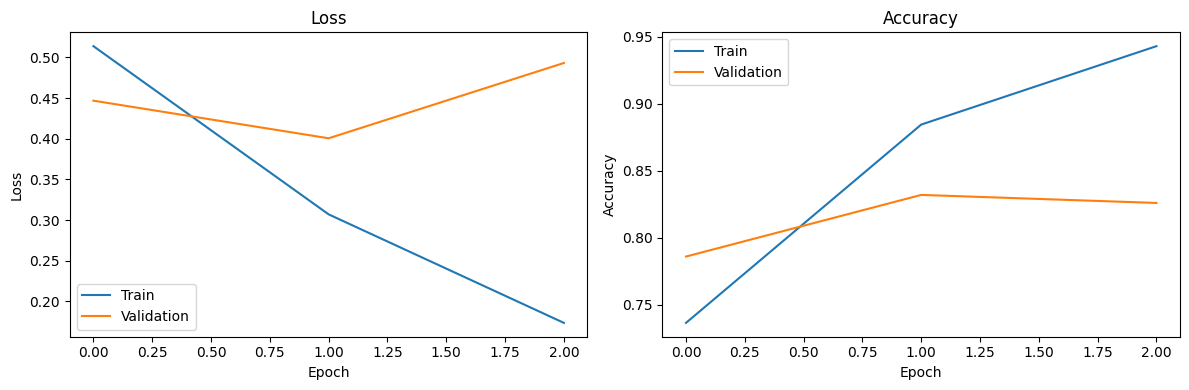

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

### Tips for Fine-Tuning

1. **Learning rate**: 2e-5 to 5e-5 is generally recommended for BERT-family models (Adam/AdamW optimizer).
2. **Epochs**: 2–4 epochs usually suffice — more can lead to overfitting on small datasets.
3. **Batch size**: 16 or 32 is typical. Larger batches need more GPU memory.
4. **Warm-up**: A learning rate warm-up schedule (linearly increasing for the first ~10% of steps) can improve stability.
5. **Hugging Face `Trainer`**: For production use, HF provides a [`Trainer`](https://huggingface.co/docs/transformers/main_classes/trainer) class that handles all of this boilerplate (and adds mixed precision, distributed training, etc.).

> **❓ Question 3: BERT Training Observations**
>
> 1. We only trained for 3 epochs and used 2,000 training examples. How does the accuracy compare to the RNN models you built in Sections 8–9 (which used the full 25,000 training set)? What explains this?
> 2. Why is `AdamW` preferred over regular `Adam` for fine-tuning transformers?
> 3. What would happen if we froze all the DistilBERT layers and only trained the classification head?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. Despite using only 2,000 examples vs 25,000, DistilBERT likely achieves comparable or better accuracy (~85–90%). This is the power of transfer learning — the model already understands language from pre-training on millions of documents.
> 2. `AdamW` applies weight decay correctly (decoupled from the gradient update), which acts as better regularization. Standard `Adam` conflates weight decay with the adaptive learning rate, which can be suboptimal for fine-tuning.
> 3. Training only the classification head would be much faster but likely yield lower accuracy. The pre-trained features are general; fine-tuning lets the model adapt its internal representations to the specific nuances of movie reviews.

</details>

## Part 3: Fine-Tuning GPT-2 for Text Generation

In Part 2 we used an **encoder** model (DistilBERT) for a classification task. Now we switch to a **decoder** model — GPT-2 — and fine-tune it on a domain-specific text generation task.

Recall from Lecture 19:
- GPT is a **decoder-only** transformer that uses **causal (masked) self-attention**
- It is an **auto-regressive** model: trained to predict the next token given all previous tokens
- BERT is a *denoising autoencoder* (bidirectional); GPT is *auto-regressive* (unidirectional)

<img src="./fig/encoder_decoder.png" width="800">

*The full Transformer has both an Encoder (red, left) and Decoder (blue, right). BERT uses only the encoder; GPT uses only the decoder (Lecture 18)*

### Encoder vs Decoder: Key Differences

| | **BERT (Encoder)** | **GPT (Decoder)** |
|---|---|---|
| **Attention** | Bidirectional (sees all tokens) | Causal (sees only past tokens) |
| **Pre-training task** | Masked Language Model (fill in blanks) | Next token prediction |
| **Best for** | Classification, NER, Q&A | Text generation, summarization |
| **Architecture** | Transformer encoder blocks | Transformer decoder blocks |

### Data Loading

We will fine-tune DistilGPT-2 on a collection of COVID-related research paper abstracts, so the model learns to generate text in a scientific writing style.

In [22]:
# Load articles (split by delimiter)
with open('data/covid_corpus.txt', 'r') as f:
    articles = [a.strip() for a in f.read().split('<<<END_OF_ARTICLE>>>') if a.strip()]

print(f'Number of articles: {len(articles)}')

Number of articles: 2009


In [23]:
# Preview a few samples
for i in range(min(3, len(articles))):
    print(f'--- Article {i} ---')
    print(articles[i][:200])
    print()

--- Article 0 ---
Here's what experts say is needed for US to return to normal. But these barriers stand in the way  (CNN)States are pushing ahead with expanding Covid-19 vaccine access and rolling back restrictions on

--- Article 1 ---
FDA, CDC advisers say to expect a lot of questions about AstraZeneca Covid-19 vaccine  (CNN)AstraZeneca is expected to apply in the next few weeks for emergency use authorization for its Covid-19 vacc

--- Article 2 ---
Covid-19 reinfections are rare, but more common in people 65 and older, study finds  (CNN)Coronavirus reinfections are relatively rare, but it's more common for people 65 and older to get infected mor



### Tokenization & Chunking

In [24]:
# Load GPT-2 tokenizer
gpt_tokenizer = AutoTokenizer.from_pretrained('distilgpt2')

# GPT-2 doesn't have a pad token by default — set it to eos_token
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

# Tokenize all articles
all_token_ids = []
for text in articles:
    tokens = gpt_tokenizer.encode(text)
    all_token_ids.append(tokens)

print(f'Tokenized {len(all_token_ids)} documents')
print(f'Total tokens: {sum(len(t) for t in all_token_ids):,}')

Token indices sequence length is longer than the specified maximum sequence length for this model (1212 > 1024). Running this sequence through the model will result in indexing errors


Tokenized 2009 documents
Total tokens: 2,690,633


In [25]:
# Split tokenized text into fixed-size chunks
BLOCK_SIZE = 100

chunks = []
for token_ids in all_token_ids:
    for i in range(0, len(token_ids) - BLOCK_SIZE + 1, BLOCK_SIZE):
        chunks.append(token_ids[i : i + BLOCK_SIZE])

print(f'Number of training chunks: {len(chunks)}')
print(f'Each chunk: {BLOCK_SIZE} tokens')

Number of training chunks: 25920
Each chunk: 100 tokens


For causal language modeling, the **input** is a sequence of tokens and the **label** is the same sequence **shifted by one** — the model learns to predict each next token.

The key mechanism that makes this work is **masked (causal) self-attention** — a lower-triangular mask zeros out attention to future tokens, so each position can only attend to itself and earlier positions:

<img src="./fig/masked_attention.png" width="800">

*Masked Multi-Head Attention Block: the mask ensures each token only attends to past tokens (Lecture 19)*

In [26]:
# For language modeling: input = tokens[:-1], label = tokens[1:]
# But HF models handle the shift internally, so we pass the same sequence as both

class TextChunkDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = chunks

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        ids = torch.tensor(self.chunks[idx], dtype=torch.long)
        # For causal LM, labels = input_ids (the model shifts internally)
        return {'input_ids': ids, 'labels': ids}

gpt_dataset = TextChunkDataset(chunks)
gpt_loader = DataLoader(gpt_dataset, batch_size=32, shuffle=True)

print(f'Training batches: {len(gpt_loader)}')

Training batches: 810


### Fine-Tuning DistilGPT-2

In [27]:
gpt_model = AutoModelForCausalLM.from_pretrained('distilgpt2').to(device)

print(f'GPT-2 parameters: {sum(p.numel() for p in gpt_model.parameters()):,}')

GPT-2 parameters: 81,912,576


In [28]:
## Runtime ~20mins on T4 colab for 3 epochs
GPT_EPOCHS = 1 #3
GPT_LR = 3e-5

gpt_optimizer = optim.AdamW(gpt_model.parameters(), lr=GPT_LR)

gpt_model.train()
for epoch in range(GPT_EPOCHS):
    total_loss = 0
    for batch in gpt_loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        gpt_optimizer.zero_grad()
        outputs = gpt_model(input_ids, labels=labels)
        loss = outputs.loss
        loss.backward()
        gpt_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(gpt_loader)
    print(f'Epoch {epoch+1}/{GPT_EPOCHS}  Loss: {avg_loss:.4f}')

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1/1  Loss: 3.4371


### Text Generation

Now we can use our fine-tuned model to generate COVID-related text. We control generation using several parameters:
- **`top_k`**: Only sample from the top-k most likely next tokens
- **`top_p`** (nucleus sampling): Sample from the smallest set of tokens whose cumulative probability ≥ p
- **`temperature`**: Higher values → more random; lower values → more deterministic
- **`do_sample`**: If `False`, uses greedy decoding (always picks the most likely token)

In [29]:
def generate_text(prompt, max_length=100, top_p=0.9, top_k=50, temperature=1.0):
    """Generate text from a prompt using the fine-tuned model."""
    gpt_model.eval()
    input_ids = gpt_tokenizer.encode(prompt, return_tensors='pt').to(device)
    attention_mask = torch.ones_like(input_ids)

    with torch.no_grad():
        output = gpt_model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_length=max_length,
            do_sample=True,
            top_p=top_p,
            top_k=top_k,
            temperature=temperature,
            pad_token_id=gpt_tokenizer.eos_token_id,
        )

    return gpt_tokenizer.decode(output[0], skip_special_tokens=True)

In [30]:
# Generate with different prompts
prompts = [
    'The impact of COVID on',
    'Vaccine development has',
    'The global pandemic',
]

for prompt in prompts:
    print(f'Prompt: "{prompt}"')
    print(f'Generated: {generate_text(prompt)}')
    print()

Prompt: "The impact of COVID on"
Generated: The impact of COVID on Covid-19, and is the same in other populations and regions," Pfizer said in an advisory.   The report also noted that the study found that more people are infected with Covid-19 than people who had not been exposed to COVID-19 or had been exposed to coronavirus-related Covid-19.    "We do not yet know whether those who did not have Covid-19 may have gotten their first doses

Prompt: "Vaccine development has"
Generated: Vaccine development has been slowed by the flu, which has killed at least 1,500 people worldwide, and more than 250,000 have been infected with the virus. It has also been the first time it has been tested in the US. The vaccine has been administered with the same precautions as the Covid-19 vaccine. But it doesn't work if you have a high-risk population, it may not work if you live in a neighborhood where some vaccines were made to last longer than

Prompt: "The global pandemic"
Generated: The global pan

In [31]:
# Compare: high temperature (more creative) vs low temperature (more conservative)
prompt = 'The impact of COVID on'

print('=== Temperature = 0.3 (conservative) ===')
print(generate_text(prompt, temperature=0.3))
print()
print('=== Temperature = 1.5 (creative) ===')
print(generate_text(prompt, temperature=1.5))

=== Temperature = 0.3 (conservative) ===


The impact of COVID on the health of the population is still unclear, but the study suggests that the virus could be a major contributor to the death rate of the US population.                                                                

=== Temperature = 1.5 (creative) ===
The impact of COVID on lung health for seniors — and the way COVID affects heart and brain, lungs and heart and lung functioning? A new report finds the long term consequences of COVID can be quite substantial — in people with preexisting cardiovascular disease.  This could include even the largest heart attack and heart attack of adult adult men over 65. The study, "Our findings offer the hope that it could be linked in any area where we are facing significant Covid pandemic


> **❓ Question 4: GPT vs BERT**
>
> 1. Could we use BERT to generate text the same way GPT does? Why or why not?
> 2. What does `top_p` (nucleus sampling) do differently from `top_k`? When might one be preferred over the other?
> 3. In the GPT training loop, why do we pass `labels=input_ids` (i.e., the labels are the same as the inputs)?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. No. BERT uses **bidirectional** attention — it sees the entire input at once, so it cannot auto-regressively generate one token at a time (it would need to see future tokens it hasn't generated yet). BERT is designed to fill in blanks (masked tokens), not generate sequences left-to-right.
> 2. `top_k` always samples from exactly k tokens regardless of their probability distribution. `top_p` adapts — it samples from the smallest set of tokens whose cumulative probability is at least p. This means `top_p` is more flexible: when the model is confident (one token has high prob), it samples from fewer tokens; when uncertain, it considers more tokens.
> 3. For causal language modeling, the task is to predict the next token at each position. The Hugging Face model internally shifts the labels by one position — so at position *i*, the model predicts token *i+1*. We pass the same IDs as both input and labels, and the model handles the alignment.

</details>

## TEAM ACTIVITY: Model Sizing, Hub Exploration & LoRA Teaser

> **🏋️ TEAM ACTIVITY:** You've just fine-tuned DistilBERT and DistilGPT-2
> end-to-end. But in practice, a critical first step is figuring out whether
> a model even *fits* on your GPU. In this activity you'll learn to estimate
> GPU memory requirements, explore the Hugging Face Model Hub to find models
> that match your hardware, and get a sneak peek at **LoRA** — a technique
> that dramatically reduces the cost of fine-tuning.

In [32]:
# Team activity setup — install additional libraries
# !pip install -q peft huggingface_hub

from huggingface_hub import HfApi
from peft import LoraConfig, get_peft_model, TaskType

**Task 1: GPU Memory Math**

You fine-tuned DistilBERT and DistilGPT-2 in Parts 2–3 without worrying
about memory. Let's make that reasoning explicit.

**Rules of thumb:**

| | Bytes per param | Notes |
|---|---|---|
| **fp32** | 4 | Default PyTorch dtype |
| **fp16 / bf16** | 2 | Mixed precision — common for inference |
| **int8** | 1 | Quantized — some accuracy trade-off |

- **Inference memory** ≈ params × bytes_per_param (just the weights + small overhead)
- **Training memory** ≈ params × bytes_per_param × **4** (weights + gradients + 2 Adam optimizer states)

> ⚠️ **These are rough lower bounds.** Real GPU memory also depends on
> sequence length, batch size, intermediate activations stored for
> backpropagation, KV-cache (for autoregressive generation), and framework
> overhead. Actual usage during training or inference will be higher —
> sometimes significantly. Still, parameter-based estimates are a useful
> first-pass sanity check before you download anything.

**Your turn:**
1. Count the parameters in DistilBERT (for classification) and DistilGPT-2.
2. Estimate GPU memory for **inference (fp16)** and **training (fp32 + Adam)**.
3. Now estimate for the larger models in the table below. Which fit on a **T4 (16 GB)** vs **L4 (24 GB)**?

| Model | Approx. params |
|---|---|
| `distilbert-base-uncased` | ~67 M |
| `bert-base-uncased` | ~110 M |
| `gpt2` | ~124 M |
| `gpt2-xl` | ~1.5 B |
| `meta-llama/Llama-3.1-8B` | ~8 B |

In [33]:
# your code here
# BEGIN SOLUTION
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def estimate_memory_gb(num_params, bytes_per_param=4, training=False):
    """Rough estimate of GPU memory in GB.
    Training with Adam: ~4x model size (weights + grads + momentum + variance).
    Note: real usage will be higher due to activations, batch size, etc.
    """
    size_bytes = num_params * bytes_per_param * (4 if training else 1)
    return size_bytes / (1024 ** 3)

# Count actual parameters for models from Parts 2-3
print('=== Models from Parts 2-3 ===')
for name, m in [('DistilBERT (cls)', model), ('DistilGPT-2', gpt_model)]:
    total, _ = count_parameters(m)
    infer_fp16 = estimate_memory_gb(total, bytes_per_param=2)
    train_fp32 = estimate_memory_gb(total, bytes_per_param=4, training=True)
    print(f'  {name}: {total:,} params')
    print(f'    fp16 inference: {infer_fp16:.2f} GB | fp32 training: {train_fp32:.2f} GB')

# Estimate for larger models (known parameter counts)
T4, L4 = 16, 24

models = [
    ('distilbert-base', 67e6),
    ('bert-base', 110e6),
    ('gpt2', 124e6),
    ('gpt2-xl', 1.5e9),
    ('Llama-3.1-8B', 8e9),
]

fmt = '{:<20} {:>8} {:>10} {:>12} {:>8} {:>10} {:>10}'
print('\n=== Scaling Up ===')
print(fmt.format('Model', 'Params', 'fp16 Inf', 'fp32 Train', 'T4 Inf?', 'T4 Train?', 'L4 Train?'))
print('-' * 82)
for name, params in models:
    infer = estimate_memory_gb(params, 2)
    train = estimate_memory_gb(params, 4, training=True)
    t4_inf = 'yes' if infer < T4 else 'NO'
    t4_trn = 'yes' if train < T4 else 'NO'
    l4_trn = 'yes' if train < L4 else 'NO'
    label = f'{params/1e6:.0f}M' if params < 1e9 else f'{params/1e9:.1f}B'
    print(fmt.format(name, label, f'{infer:.2f} GB', f'{train:.2f} GB', t4_inf, t4_trn, l4_trn))
# END SOLUTION

=== Models from Parts 2-3 ===
  DistilBERT (cls): 66,955,010 params
    fp16 inference: 0.12 GB | fp32 training: 1.00 GB
  DistilGPT-2: 81,912,576 params
    fp16 inference: 0.15 GB | fp32 training: 1.22 GB

=== Scaling Up ===
Model                  Params   fp16 Inf   fp32 Train  T4 Inf?  T4 Train?  L4 Train?
----------------------------------------------------------------------------------
distilbert-base           67M    0.12 GB      1.00 GB      yes        yes        yes
bert-base                110M    0.20 GB      1.64 GB      yes        yes        yes
gpt2                     124M    0.23 GB      1.85 GB      yes        yes        yes
gpt2-xl                  1.5B    2.79 GB     22.35 GB      yes         NO        yes
Llama-3.1-8B             8.0B   14.90 GB    119.21 GB      yes         NO         NO


**Task 2: Hugging Face Hub Scavenger Hunt**

The [Hugging Face Model Hub](https://huggingface.co/models) hosts hundreds
of thousands of models. Learning to navigate it is a practical skill you'll
use constantly. Use the `HfApi` Python client **and/or** browse the Hub
website to complete these challenges.

**Challenges:**

1. **Most popular** — Find the 5 most downloaded models for `text-generation`.
   Which one tops the list?
2. **Budget GPU** — Find a **summarization** model that could run inference
   in fp16 on a **T4 (16 GB)**. What's its name and approximate size?
3. **Model card detective** — Pick any model from your searches. Open its
   model card on the Hub. What training data was it built on? Does it list
   limitations? What license does it use?
4. **Wild card** — Find the most *unusual* or surprising model on the Hub.
   What does it do?

*Hint: `HfApi().list_models(pipeline_tag=..., sort='downloads')` is
your starting point.*

In [34]:
# your code here
# BEGIN SOLUTION
api = HfApi()

# Challenge 1: Most downloaded text-generation models
print('=== Challenge 1: Top text-generation models ===')
gen_models = list(api.list_models(
    pipeline_tag='text-generation', sort='downloads', limit=5
))
for m in gen_models:
    print(f'  {m.id:<45} downloads: {m.downloads:>12,}')

# Challenge 2: Summarization models
print('\n=== Challenge 2: Summarization models ===')
sum_models = list(api.list_models(
    pipeline_tag='summarization', sort='downloads', limit=5
))
for m in sum_models:
    print(f'  {m.id:<45} downloads: {m.downloads:>12,}')

print('\n  -> facebook/bart-large-cnn (~406M params)')
print('     fp16 inference: ~0.76 GB — easily fits on T4!')

# Challenges 3 & 4: Browse https://huggingface.co/models and discuss!
print('\n=== Challenges 3 & 4 ===')
print('Browse https://huggingface.co/models and discuss with your team!')
# END SOLUTION

=== Challenge 1: Top text-generation models ===
  Qwen/Qwen3-0.6B                               downloads:   14,197,109
  Qwen/Qwen2.5-7B-Instruct                      downloads:   13,130,797
  openai-community/gpt2                         downloads:   13,073,357
  Qwen/Qwen2.5-1.5B-Instruct                    downloads:    9,853,843
  Qwen/Qwen3-8B                                 downloads:    9,286,171

=== Challenge 2: Summarization models ===
  facebook/bart-large-cnn                       downloads:    1,985,619
  sshleifer/distilbart-cnn-12-6                 downloads:      645,833
  google/pegasus-xsum                           downloads:      330,240
  philschmid/bart-large-cnn-samsum              downloads:      170,790
  EbanLee/kobart-summary-v3                     downloads:       76,064

  -> facebook/bart-large-cnn (~406M params)
     fp16 inference: ~0.76 GB — easily fits on T4!

=== Challenges 3 & 4 ===
Browse https://huggingface.co/models and discuss with your team!


**Task 3: LoRA Teaser — Shrinking the Trainable Footprint**

Looking at the table from Task 1, training large models requires *a lot* of
memory. What if you could fine-tune a model while updating less than
**1%** of its parameters?

**LoRA (Low-Rank Adaptation)** does exactly this:
1. **Freeze** the entire pre-trained model
2. Inject small **low-rank adapter matrices** into selected layers
3. Only train these tiny adapters

For a weight matrix **W** of size (d × d), LoRA adds two small matrices
**A** (d × r) and **B** (r × d), where r ≪ d is the **rank**.
New trainable parameters per module = 2 × d × r.

<img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/peft/lora_diagram.png" width="500">

**Your turn:**
1. Apply LoRA to the DistilBERT model from Part 2 using the `peft` library.
2. Compare total vs. trainable parameter counts.
3. Calculate how LoRA parameter counts scale with rank (r = 2, 4, 8, 16, 32, 64).

In [35]:
# your code here
# BEGIN SOLUTION
# Reload a fresh DistilBERT for classification
base_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
full_params = sum(p.numel() for p in base_model.parameters())
full_train_mem = full_params * 16 / 1e9  # fp32 weights+grads+optimizer
print(f'Full model: {full_params:,} parameters')
print(f'Full-model training memory (fp32 + Adam): {full_train_mem:.2f} GB\n')

# Apply LoRA — freeze base model, add small trainable adapters
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                                # rank of low-rank matrices
    lora_alpha=16,                      # scaling factor
    target_modules=['q_lin', 'v_lin'],  # adapt query & value projections
    lora_dropout=0.1,
)

lora_model = get_peft_model(base_model, lora_config)
print('With LoRA (rank=8):')
lora_model.print_trainable_parameters()

# How does rank affect the parameter count?
d = 768   # DistilBERT hidden size
n_modules = 2  # q_lin + v_lin per layer
n_layers = 6   # DistilBERT transformer layers

fmt = '{:>6} {:>14} {:>16} {:>14}'
print(f'\n{fmt.format("Rank", "LoRA Params", "% of Full Model", "Train Memory")}')
print('-' * 54)
for r in [2, 4, 8, 16, 32, 64]:
    lora_params = 2 * d * r * n_modules * n_layers
    pct = 100 * lora_params / full_params
    # With LoRA: base model stored in fp16, only adapters need full training state
    mem_gb = (full_params * 2 + lora_params * 16) / 1e9
    print(fmt.format(r, f'{lora_params:,}', f'{pct:.2f}%', f'{mem_gb:.3f} GB'))

print(f'\nFull fine-tuning memory:  {full_train_mem:.2f} GB')
print(f'LoRA (rank=8) memory:    {(full_params * 2 + 2*768*8*2*6 * 16) / 1e9:.3f} GB')
# END SOLUTION

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Full model: 66,955,010 parameters
Full-model training memory (fp32 + Adam): 1.07 GB

With LoRA (rank=8):
trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925

  Rank    LoRA Params  % of Full Model   Train Memory
------------------------------------------------------
     2         36,864            0.06%       0.134 GB
     4         73,728            0.11%       0.135 GB
     8        147,456            0.22%       0.136 GB
    16        294,912            0.44%       0.139 GB
    32        589,824            0.88%       0.143 GB
    64      1,179,648            1.76%       0.153 GB

Full fine-tuning memory:  1.07 GB
LoRA (rank=8) memory:    0.136 GB


**Task 4: Discussion**

Discuss with your team:

1. A collaborator wants to fine-tune **Llama-3.1-8B** on a single **L4
   (24 GB)**. Based on your memory estimates, is this feasible with standard
   fine-tuning? What about with LoRA (keeping the base model in fp16 and
   only training small adapters)?

2. You need to deploy a **text summarization** model in a production API
   with strict latency requirements. Would you choose a smaller specialized
   model (e.g. BART-large, 406 M params) or a larger general-purpose model
   (e.g. Llama-8B) with quantization? What factors beyond memory would
   influence your decision?

3. When browsing the Hub, what information on a **model card** helped you
   decide whether a model is suitable for your use case?

**End of team activity**

In [36]:
time_end = time.time()
print(f'Notebook completed in {(time_end - time_start) / 60:.2f} minutes')

Notebook completed in 0.79 minutes
